In [1]:
import json

import matplotlib.pyplot as plt 
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
from matplotlib import cm
import numpy as np

tex_rc_params = {
    'backend': 'ps',
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'legend.fontsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': 'serif',
}

%matplotlib inline
%config InlineBackend.figure_format='retina'  # for hi-dpi displays


In [6]:
results = []

filename = "coherent_information_moebius_length_5_width_5_p_3.json"
with open(filename) as file_data:
    results.append(json.load(file_data))

filename = "coherent_information_moebius_length_5_width_5_p_3_gamma_min_0.08_gamma_max_0.5_num_gamma_50.json"
with open(filename) as file_data:
    results.append(json.load(file_data))

# filename = "coherent_information_moebius_length_7_width_7_p_3.json"
# with open(filename) as file_data:
#     results.append(json.load(file_data))

# filename = "coherent_information_moebius_length_9_width_9_p_3.json"
# with open(filename) as file_data:
#     results.append(json.load(file_data))

# filename = "coherent_information_moebius_length_11_width_11_p_3.json"
# with open(filename) as file_data:
#     results.append(json.load(file_data))

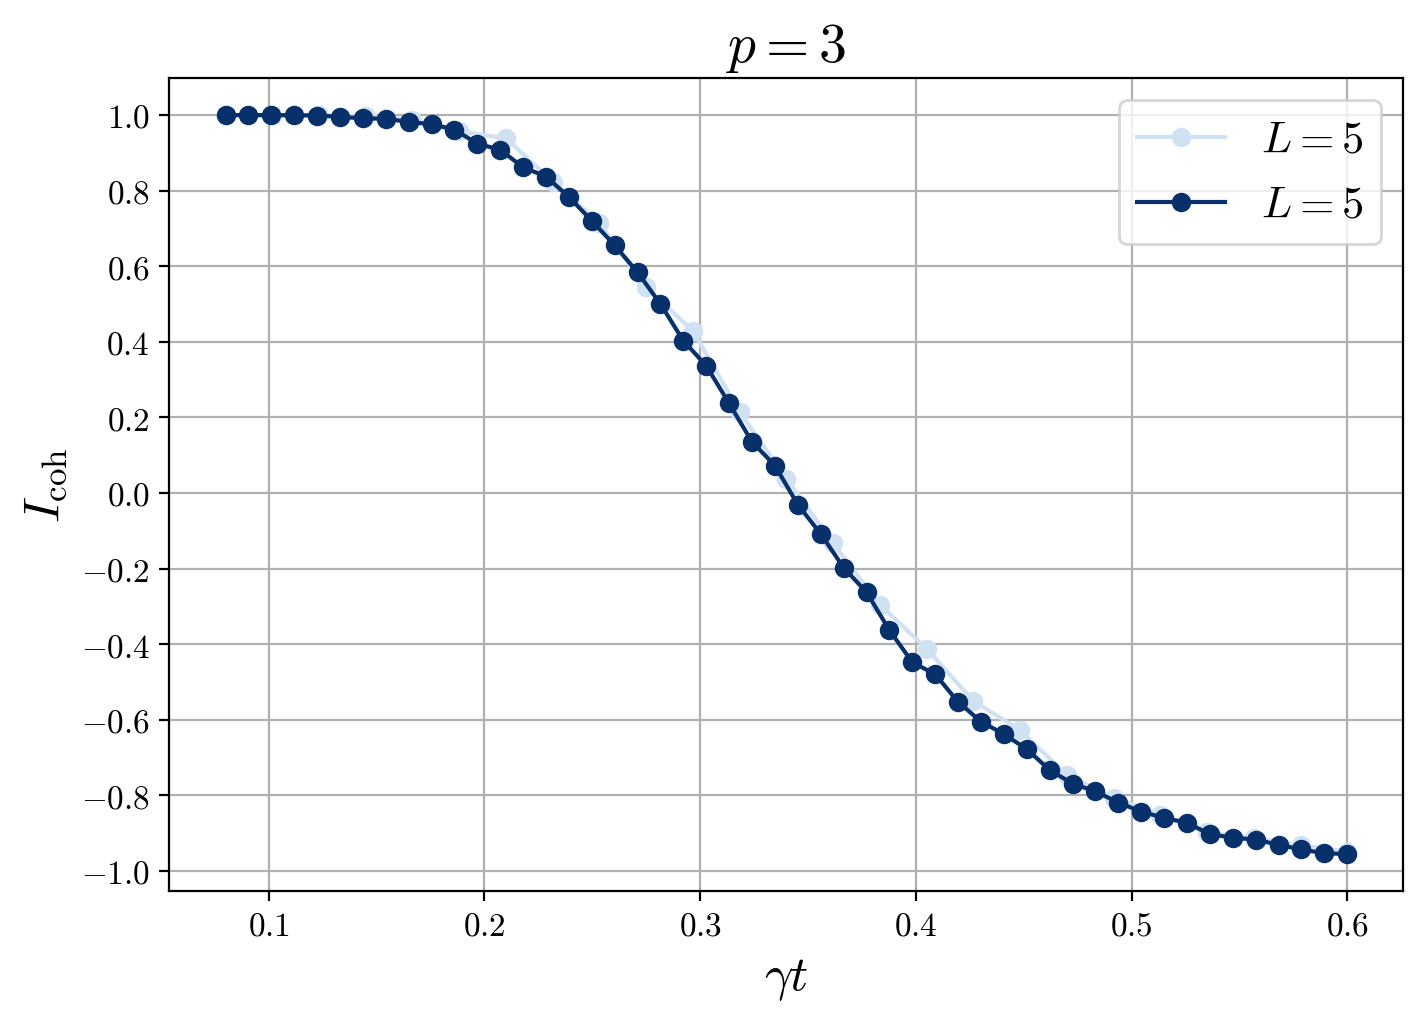

In [7]:
def plot_coherent_information(
    results: list,
    save: bool=False
):
    # length = result["moebius_setup"]["length"]
    # width = result["moebius_setup"]["width"]
    # p = result["moebius_setup"]["p"]
    # gamma_array = result["gamma_t"]
    # coherent_info_array = result["coherent_information"]
    blues =  matplotlib.colormaps["Blues"]
    color_index = (np.linspace(0.2, 1.0, len(results))).tolist()
    colors = [blues(x) for x in color_index]
    with plt.rc_context(tex_rc_params):
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
        for result, color in zip(results, colors):
            length = result["moebius_setup"]["length"]
            width = result["moebius_setup"]["width"]
            p = result["moebius_setup"]["p"]
            gamma_array = result["gamma_t"]
            coherent_info_array = result["coherent_information"]

            ax.plot(gamma_array, coherent_info_array, '-o', color=color, label=f"$L={length}$")
        ax.set_xlabel("$\\gamma t$")
        x_ticks = [0.1 + 0.1 * x for x in range(6)]
        ax.set_xticks(x_ticks)
        x_ticks_labels = ['$0.1$', '$0.2$', '$0.3$', '$0.4$', '$0.5$', '$0.6$']
        ax.set_xticklabels(x_ticks_labels)
        y_ticks = [-1.0 + 0.2 * y for y in range(11)]
        ax.set_yticks(y_ticks)
        y_ticks_labels = ['$-1.0$', '$-0.8$', '$-0.6$', '$-0.4$', '$-0.2$', '$0.0$',
                          '$0.2$', '$0.4$', '$0.6$', '$0.8$', '$1.0$']
        ax.set_yticklabels(y_ticks_labels)
        ax.set_ylabel("$I_{\\mathrm{coh}}$")
        ax.grid()
        ax.set_title(f"$p={p}$")
        ax.legend(loc='best')
        filename = ("coherent_information_moebius_p" + str(p) + ".json")
        if save:
            plt.savefig(filename + ".svg", bbox_inches='tight', 
                        transparent=True, pad_inches=0)
            plt.savefig(filename + ".pdf", bbox_inches='tight', 
                        transparent=True, pad_inches=0)
            plt.savefig(filename + ".png", bbox_inches='tight', 
                        transparent=True, pad_inches=0)
        plt.show()

plot_coherent_information(results, False)

Here we see only marginal change by taking more samples (dark blue)